### Re-examine and debug the relationship between choice and pref. 
Copying impls from /src/wcst_decode/notebooks/20250707_choice_preference_relationship.ipynb

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
import utils.information_utils as information_utils
import utils.visualization_utils as visualization_utils
import utils.pseudo_classifier_utils as pseudo_classifier_utils
import utils.classifier_utils as classifier_utils

import utils.io_utils as io_utils

import utils.glm_utils as glm_utils
from matplotlib import pyplot as plt
import matplotlib
import utils.spike_utils as spike_utils
import utils.subspace_utils as subspace_utils
from trial_splitters.condition_trial_splitter import ConditionTrialSplitter 
from utils.session_data import SessionData
from constants.behavioral_constants import *
from constants.decoding_constants import *
import seaborn as sns
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io

import scipy
import argparse
import copy
from tqdm import tqdm

In [3]:
args = argparse.Namespace(
    **BeliefPartitionConfigs()._asdict()
)
args.trial_event = "FeedbackOnsetLong"
args.subject = "both"


In [ ]:
all_sims = []
for feat in FEATURES:
    args.feat = feat
    pref_args = copy.deepcopy(args)
    pref_args.sig_unit_level = "pref_99th_window_filter_drift"
    pref_args.beh_filters = {"Response": "Correct", "Choice": "Chose"}

    pref_args.mode = "pref"
    pref_weights = belief_partitions_io.get_weights(pref_args)
    pref_weights["Time_milli"] = (pref_weights["TimeIdx"] * 100).astype(int)

    choice_args = copy.deepcopy(args)
    choice_args.base_output_path = "/data/patrick_res/choice_reward"
    choice_args.sig_unit_level = "choice_99th_window_filter_drift"
    choice_args.beh_filters = {"Response": "Correct", "Choice": "Chose"}

    choice_args.mode = "choice"

    # choice_args.mode = "choice"

    choice_weights = belief_partitions_io.get_weights(choice_args)  
    # choice_weights["Time_milli"] = (choice_weights["Time"] * 1000).astype(int)
    choice_weights["Time_milli"] = (choice_weights["TimeIdx"] * 100).astype(int)
    merged = pd.merge(choice_weights, pref_weights, on=["PseudoUnitID", "feat"], suffixes=("_choice", "_pref"), how="outer").fillna(0)
    sims = merged.groupby(["Time_milli_choice", "Time_milli_pref", "feat"]).apply(lambda x: classifier_utils.cosine_sim(x.weightsdiff_normed_choice, x.weightsdiff_normed_pref)).reset_index(name="cosine_sim")
    all_sims.append(sims)   
all_sims_df = pd.concat(all_sims, ignore_index=True)

FileNotFoundError: [Errno 2] No such file or directory: '/data/patrick_res/choice_reward/both_FeedbackOnsetLong_Response_Correct_choice_99th_window_filter_drift_units/CIRCLE_choice_models.npy'

In [8]:
sims_means = all_sims_df.groupby(["Time_milli_choice", "Time_milli_pref"]).agg({"cosine_sim": "mean"}).reset_index()


<Axes: xlabel='Time_milli_choice', ylabel='Time_milli_pref'>

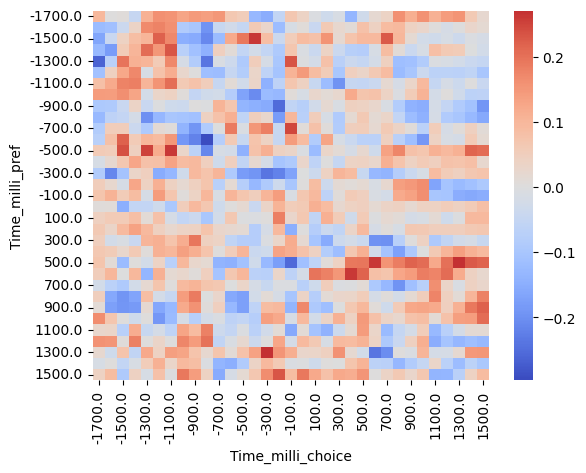

In [9]:
pivoted = sims_means.pivot(index="Time_milli_pref", columns="Time_milli_choice", values="cosine_sim")
sns.heatmap(pivoted, cmap='coolwarm', center=0)

In [13]:
sims_means_diag = all_sims_df[all_sims_df["Time_milli_choice"] == all_sims_df["Time_milli_pref"]]

<Axes: xlabel='Time_milli_choice', ylabel='cosine_sim'>

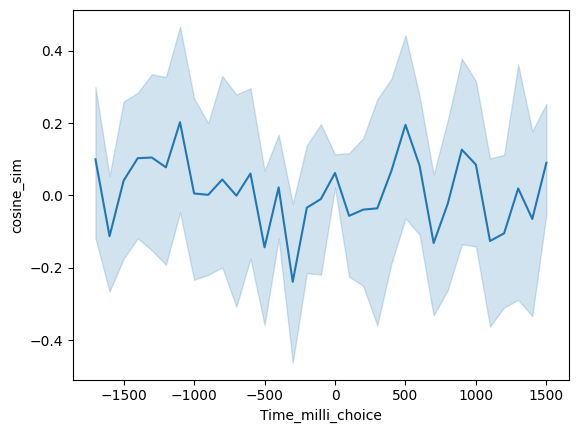

In [15]:
sns.lineplot(data=sims_means_diag, x="Time_milli_choice", y="cosine_sim")